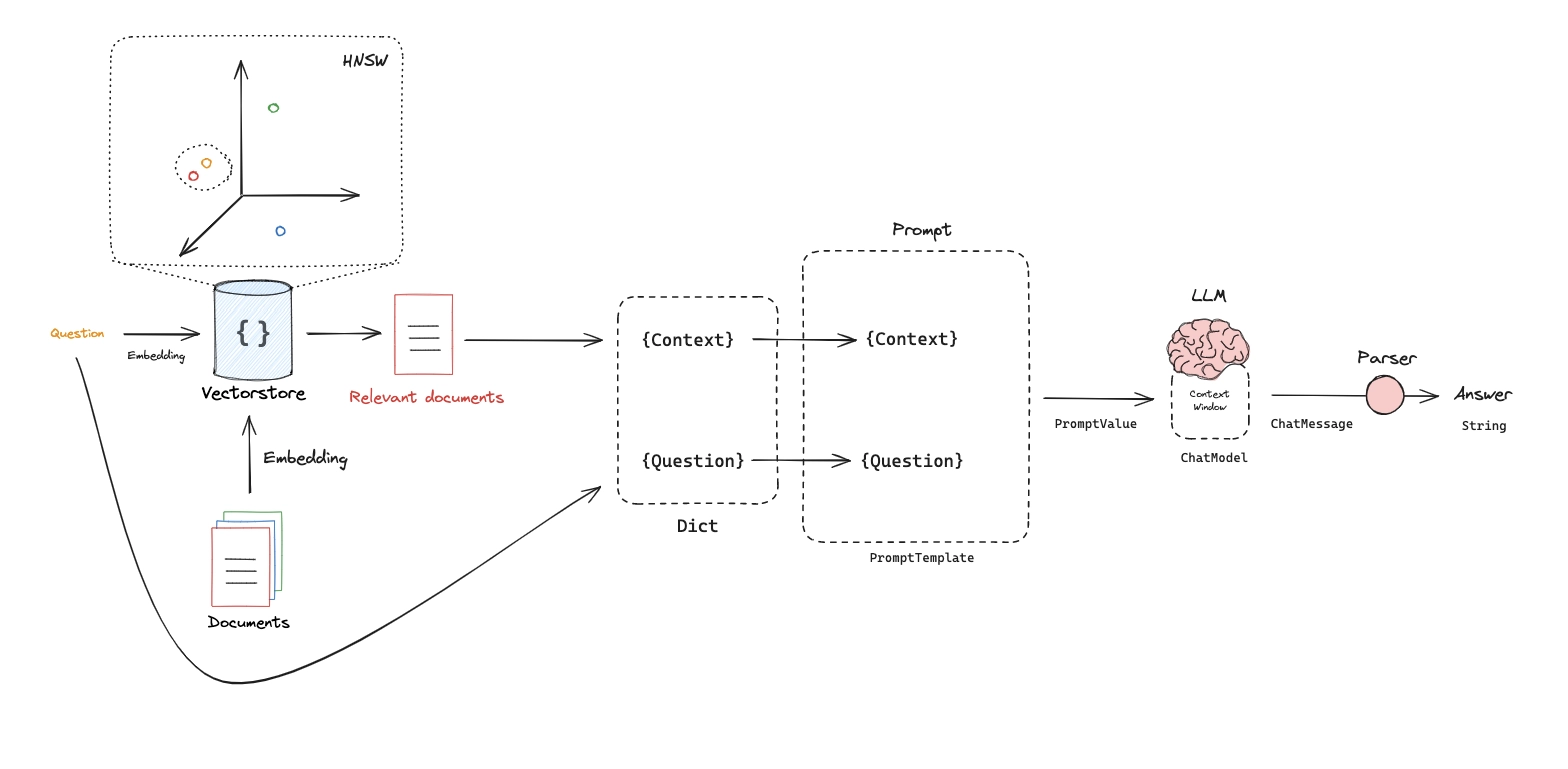

# Как работает RAG

## **I. Индексация**

1. **Загрузка**: загрузчики документов (PDF, текст, etc)
см тут: https://docs.langchain.com/oss/python/integrations/document_loaders#pdfs

Вот конспект по document loaders, только самое нужное.

**PDF**
PyPDF — базовый, простой текст. PyMuPDF4LLM — конвертирует в markdown, сохраняет заголовки. PDFPlumber — хорош для таблиц. MathPix — формулы как картинки (платный). Amazon Textract — OCR через AWS (платный).

**Веб**
WebBaseLoader — простой HTML через BeautifulSoup, статичные сайты. RecursiveURL — рекурсивно обходит весь сайт по ссылкам от одного URL. Sitemap — грузит все страницы через sitemap.xml. FireCrawl / Spider — платные API, сразу отдают чистый markdown, не надо чистить HTML. Apify — готовые парсеры под конкретные сложные сайты (LinkedIn, Instagram и тд), платно.

**Соцсети и мессенджеры**
Twitter, Reddit — прямые загрузчики постов. Telegram, Discord, WhatsApp — экспорт истории чатов.

**Файлы**
CSV, JSON, HTML — из коробки. Microsoft Word, Excel, PowerPoint — есть отдельные лоадеры. Unstructured — универсальный, тянет почти любой формат.

**Продуктивность**
Notion, Slack, GitHub, Google Drive — прямые интеграции через API.

**Специализированные**
RSS Feeds — новостные ленты без написания парсера. YouTube — транскрипты видео. Arxiv — научные статьи по запросу или ID. PubMed — медицина и наука. Wikipedia — напрямую. HuggingFace Dataset — датасеты с HF.

2. **Разделение**: разбиваем большие документы на чанки
см тут: https://docs.langchain.com/oss/python/integrations/splitters

3. **Store**: векторное хранилище + embeddings для поиска

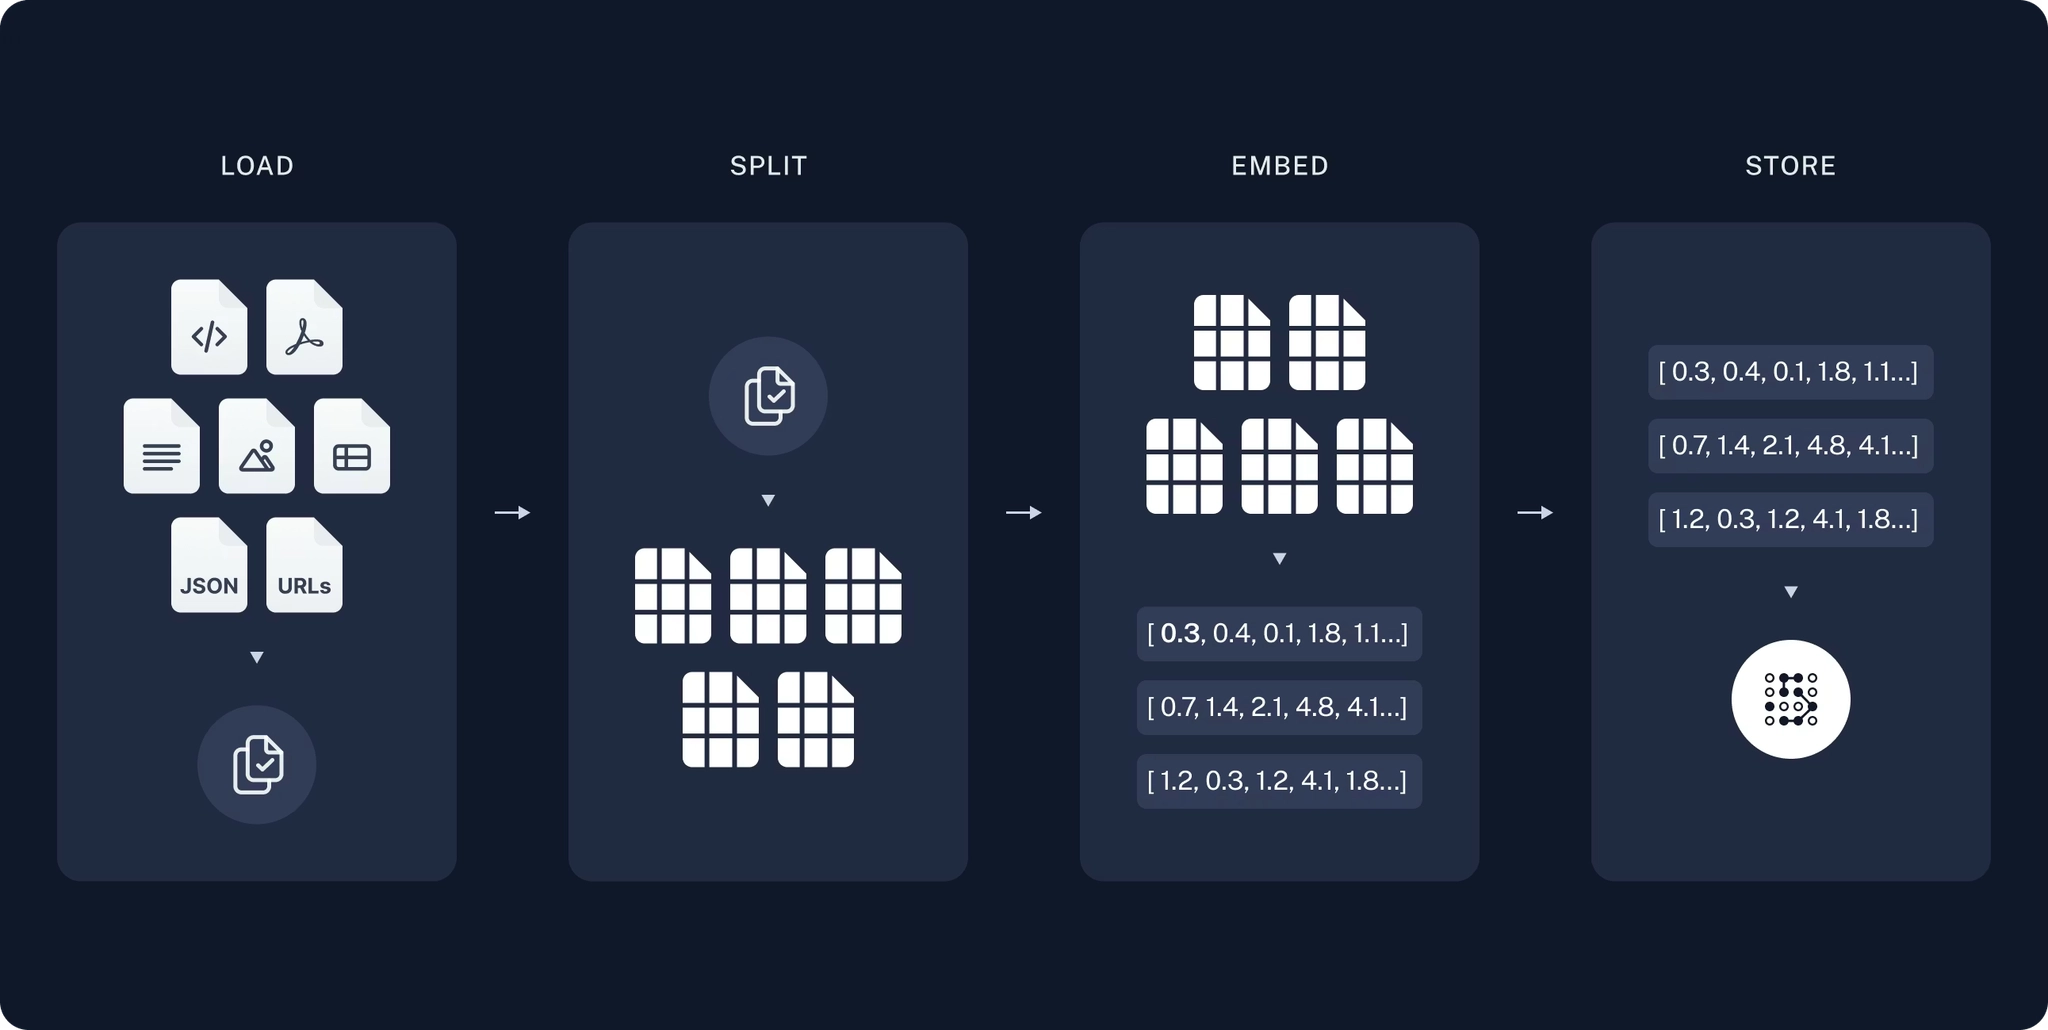


### **Загрузка документов**

TextLoader загружает любые обычные текстовые файлы (.txt, .md, .log и т. д.) и просто читает их содержимое как единый сплошной текст. Он не анализирует структуру документа, не делит его на страницы и не восстанавливает форматирование – результатом всегда будет один Document с текстом, считанным "как есть".

In [1]:
# from langchain_community.document_loaders import TextLoader

# loader = TextLoader("blabla", encoding="utf-8")
# docs = loader.load()

In [2]:
# загрузка всех !!! PDF из папки, страницы одного файла объединяются в один Document ---

from langchain_community.document_loaders import PyPDFLoader
from langchain_core.documents import Document
from pathlib import Path
import time

start_load = time.time()
print("📚 Загрузка PDF с объединением страниц...\n")

materials_dir = Path("./materials")
pdf_files = sorted(materials_dir.glob("*.pdf"))

docs = []
for pdf_path in pdf_files:
    print(f"  Загружаю: {pdf_path.name}")
    loader = PyPDFLoader(str(pdf_path))
    pages = loader.load()
    # объединяем все страницы одного файла в один Document
    combined_text = "\n\n".join(p.page_content for p in pages)
    combined_doc = Document(
        page_content=combined_text,
        metadata={"source": str(pdf_path)},
    )
    docs.append(combined_doc)
    print(f"    → {len(pages)} страниц → 1 документ ({len(combined_text):,} сим)")

print(f"\n✅ Загружено документов: {len(docs)} (файлов: {len(pdf_files)})")

elapsed_load = time.time() - start_load
print(f"⏱ Время загрузки: {elapsed_load:.2f} секунд\n")

# all unique sources
sources = set(d.metadata.get("source", "") for d in docs)
print(f"📂 Уникальные источники: {len(sources)}")

/home/emkex/life/capital/areas/code/ai_engineer/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


📚 Загрузка PDF с объединением страниц...

  Загружаю: MATH_EV_PCA.pdf
    → 46 страниц → 1 документ (13,690 сим)
  Загружаю: MATH_limits.pdf
    → 39 страниц → 1 документ (9,405 сим)
  Загружаю: ML3.pdf
    → 31 страниц → 1 документ (9,983 сим)

✅ Загружено документов: 3 (файлов: 3)
⏱ Время загрузки: 1.47 секунд

📂 Уникальные источники: 3


### **Разделение документов**

Разбиваем большой документ на чанки. Есть несколько способов:
- По символам (RecursiveCharacterTextSplitter)
- По структуре/заголовкам (MarkdownHeaderTextSplitter)
- По предложениям (NLTKTextSplitter)


In [3]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from pathlib import Path
import time
import statistics

# docs уже загружены из папки выше

# для замера времени обработки
start_time = time.time()
print("📄 Обработка документов по символам...")

other_docs = [d for d in docs]
print(f"  Документов: {len(other_docs)} страниц")

other_splitter = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", ". ", " ", ""],
    chunk_size=1000,
    chunk_overlap=200,
)

chunks = other_splitter.split_documents(other_docs)
print(f"  ✓ Разделено на: {len(chunks)} чанков")
print(f"  Размер: {min(len(c.page_content) for c in chunks)}-{max(len(c.page_content) for c in chunks)} сим\n")

# прошло времени
elapsed_time_2 = time.time() - start_time
print(f"⏱ Время обработки документов: {elapsed_time_2:.2f} секунд\n")

print(f"✅ ИТОГО: {len(chunks)} чанков")

# Примеры
print("\n📌 ПРИМЕРЫ ЧАНКОВ:")
for i, chunk in enumerate(chunks[:3]):
    print(f"\n--- Чанк {i+1} (Источник: {Path(chunk.metadata.get('source', '')).name}) ---")
    print(f"Размер: {len(chunk.page_content)} символов")
    print(f"Содержание (первые 500 сим):\n{chunk.page_content[:500]}")

# --- КОНТРОЛЬ ПОТЕРЬ ПРИ ПАРСИНГЕ ---
print("\n🔍 КОНТРОЛЬ КАЧЕСТВА:")

# Суммируем текст во всех документах
original_total = sum(len(d.page_content) for d in docs)
print(f"  Оригинальный текст: {original_total:,} символов")

# Суммируем текст во всех чанках
chunks_total = sum(len(c.page_content) for c in chunks)
print(f"  После чанкования: {chunks_total:,} символов")

# Потери из-за overlap (нормально, это контролируемо)
loss_percent = (1 - chunks_total / original_total) * 100
print(f"  Потери: {loss_percent:.1f}% (overlap + граничные символы)\n")

# Проверяем чанки по источникам
print("  По источникам:")
for source in sources:
    source_docs = [d for d in docs if d.metadata.get("source") == source]
    source_chunks = [c for c in chunks if c.metadata.get("source") == source]
    source_chars = sum(len(d.page_content) for d in source_docs)
    print(f"    {Path(source).name}: {len(source_docs)} стр. → {len(source_chunks)} чанков ({source_chars:,} сим)")

# --- СТАТИСТИКА ПО РАЗМЕРАМ ЧАНКОВ ---
print("\n📊 СТАТИСТИКА ЧАНКОВ:")

chunk_lengths = [len(c.page_content) for c in chunks]
print(f"  Средний размер: {statistics.mean(chunk_lengths):.1f} символов")
print(f"  Медиана: {statistics.median(chunk_lengths):.1f} символов")
print(f"  Минимум: {min(chunk_lengths)} символов")
print(f"  Максимум: {max(chunk_lengths)} символов")

📄 Обработка документов по символам...
  Документов: 3 страниц
  ✓ Разделено на: 45 чанков
  Размер: 429-993 сим

⏱ Время обработки документов: 0.00 секунд

✅ ИТОГО: 45 чанков

📌 ПРИМЕРЫ ЧАНКОВ:

--- Чанк 1 (Источник: MATH_EV_PCA.pdf) ---
Размер: 835 символов
Содержание (первые 500 сим):
3. Матричные разложения
• выпускница механико-математического факультета МГУ
• преподаватель и автор курсов для бакалавриата Центрального Университета (Т-Банк)
• спикер и методист для магистратуры Edutoria (Сбербанк)
• участница конференций и научных форумов по теории вероятностей
Математика для Data Science
Ксения Кондаурова

План вебинара
• собственные векторы и собственные значения линейного преобразования
• спектральное разложение
• ортогональные и симметричные матрицы
• сингулярное разложен

--- Чанк 2 (Источник: MATH_EV_PCA.pdf) ---
Размер: 976 символов
Содержание (первые 500 сим):
Отображение 𝐿: ℝ𝒏 ⟶  ℝ𝒎 линейного пространства   ℝ𝒏 в линейное пространство   ℝ𝒎
называется линейным оператором, если

### Создаём embeddings

После разбиения текста на чанки нам нужно преобразовать каждый фрагмент в числовое представление – **эмбеддинг**.

Эмбеддинги – это векторы из десятков, сотен или тысяч чисел, и каждый такой вектор – это точка в многомерном пространстве. В этом пространстве смысловые связи отражаются геометрически: похожие тексты оказываются "близко" друг к другу, а непохожие – далеко. Векторное хранилище (например, Chroma, Qdrant или Pinecone) сохраняет эти точки и позволяет быстро находить ближайшие, измеряя расстояние между ними через cosine similarity, dot product или другую метрику. Именно это и делает возможным семантический поиск: модель не ищет совпадение слов – она ищет **смысловую близость в пространстве эмбеддингов**.
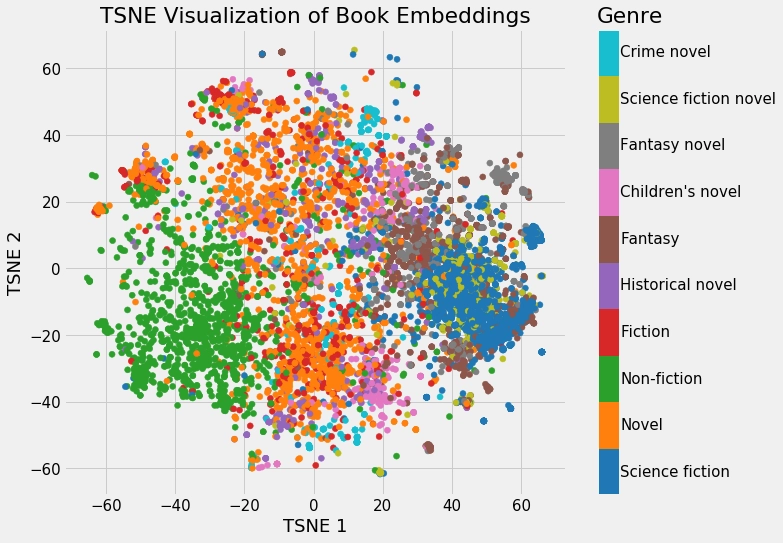

Модель для создания эмбеддингов – это специальная нейросеть, которая преобразует текст в такие векторные представления и позволяет выполнять семантический поиск по базе документов.
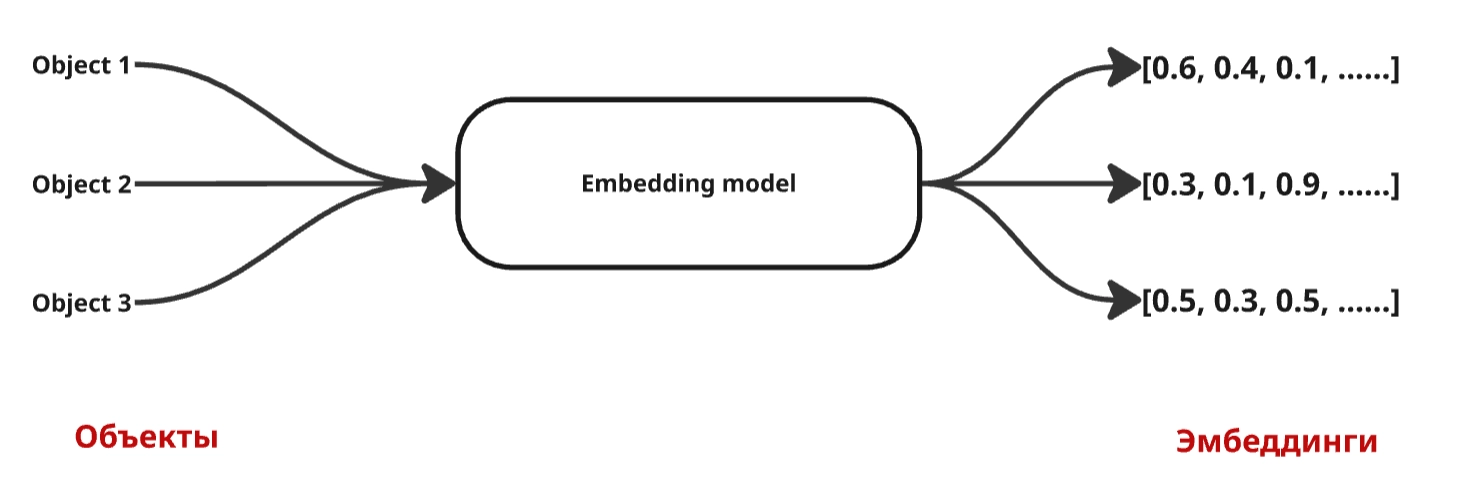

От выбора embedding-модели зависит качество поиска: чем лучше она понимает язык и контекст, тем точнее система сможет находить нужные фрагменты. Выбор модели определяется языком данных, доступными ресурсами (нужна ли локальная модель или облачная) и требуемым балансом между скоростью, стоимостью и качеством.

Здесь https://docs.langchain.com/oss/python/integrations/embeddings главное не список провайдеров (их 70+, большинство не нужны), а концепции.

**Суть**

Embedding модель — отдельная от LLM. LLM отвечает на вопросы, embedding модель только переводит текст в векторы. Это разные задачи, разные модели.

Два метода у любой embedding модели: `embed_documents(texts)` — векторизует список чанков (при индексации), `embed_query(text)` — векторизует один вопрос (при поиске).

**Метрики схожести** — cosine similarity (угол между векторами), Euclidean distance (расстояние), dot product. На практике везде используют cosine similarity.

**Провайдеры которые реально нужны**

`OllamaEmbeddings` — локально, бесплатно, твой текущий вариант (snowflake-arctic). `OpenAIEmbeddings` — платно, но качественно, `text-embedding-3-small` дёшево. `HuggingFaceEmbeddings` — запускаешь модель с HF локально через `sentence-transformers`. `NomicEmbeddings` — хорошая бесплатная модель, поддерживает мультиязычность. `FakeEmbeddings` — для тестов, не считает реальные векторы.

**Кэширование**

`CacheBackedEmbeddings` — обёртка которая сохраняет уже посчитанные векторы на диск. Если тот же текст встретится снова — не пересчитывает, берёт из кэша. 

Для нашего примера возьмём локальную какую-нибудь эмбединг модель с [Hugging Face](https://huggingface.co/models) и запустим её локально через Ollama. Пример запроса:

[https://huggingface.co/models?**apps=ollama&language=ru&sort=trending&search=embed**](https://huggingface.co/models?apps=ollama&language=ru&sort=trending&search=embed)


In [4]:
# --- ТЕСТ: запрос к API для получения эмбеддингов ---
import requests

r = requests.post("http://localhost:11434/api/embeddings", json={
    "model": "hf.co/Casual-Autopsy/snowflake-arctic-embed-l-v2.0-gguf:Q4_K_M",
    "prompt": "wateremelons are not tasty",
})
print(r.json()["embedding"][:10], "...")

[0.5312023758888245, 0.6521092653274536, 0.5985397696495056, -1.5771807432174683, 0.0051862820982933044, -0.3054230511188507, -0.22842010855674744, 0.3521425426006317, -0.28601962327957153, -0.03768999129533768] ...


In [5]:
# --- ТЕСТ: использование класса OllamaEmbeddings ---
from langchain_ollama import OllamaEmbeddings

EMBEDDING_MODEL = 'hf.co/Casual-Autopsy/snowflake-arctic-embed-l-v2.0-gguf:Q4_K_M'
OLLAMA_BASE_URL = 'http://127.0.0.1:11434'

embeddings = OllamaEmbeddings(
    model=EMBEDDING_MODEL,      # имя модели в ollama
    base_url=OLLAMA_BASE_URL,   # стандартный адрес ollama
)

example_req = embeddings.embed_query("what is the meaning of 67?")
print(len(example_req), example_req[:10], "...")

1024 [0.02804359, -0.025206562, 0.002376094, -0.033253487, -0.028425762, -0.07306495, 0.04791903, 0.0420879, 0.027418898, -0.014155072] ...


In [6]:
# cosine similarity function for embeddings (just testing)

from sklearn.metrics.pairwise import cosine_similarity

# Cosine similarity — мера похожести между двумя векторами (от 0 до 1)
# 1 = идентичные векторы (одинаковые направления)
# 0 = ортогональные (совсем не похожи)

# Пример с вопросами про небо и солнце
print("☀️  Пример: вопросы про небо и солнце")
q1_embedding = embeddings.embed_query("где находится солнце")
q2_embedding = embeddings.embed_query("где находится небо")
q3_embedding = embeddings.embed_query("какой размер видеокарты")

sim_sun_sky = cosine_similarity([q1_embedding], [q2_embedding])[0][0]
sim_sun_gpu = cosine_similarity([q1_embedding], [q3_embedding])[0][0]

print(f"  'Где солнце' vs 'Где небо': {sim_sun_sky:.4f} (похожие темы)")
print(f"  'Где солнце' vs 'Размер видеокарты': {sim_sun_gpu:.4f} (не похожи)\n")


☀️  Пример: вопросы про небо и солнце
  'Где солнце' vs 'Где небо': 0.7128 (похожие темы)
  'Где солнце' vs 'Размер видеокарты': 0.0882 (не похожи)



### **Хранение документов**

link: https://docs.langchain.com/oss/python/integrations/vectorstores

Теперь нам нужно проиндексировать все фрагменты текста, чтобы мы могли выполнять поиск по ним во время выполнения программы. Для этого мы будем использовать векторное хранилище. 

**Векторное хранилище** – это специализированная база данных, оптимизированная для хранения эмбеддингов и поиска ближайших векторов. Обычные базы данных умеют искать по точным совпадениям, но совершенно не подходят для задач семантического поиска, где два текста могут быть написаны разными словами, но иметь одинаковый смысл. Векторное хранилище позволяет эффективно работать с многомерными пространствами, в которых каждая точка представляет смысловую сущность, а поиск осуществляется через сравнение расстояний между векторами.

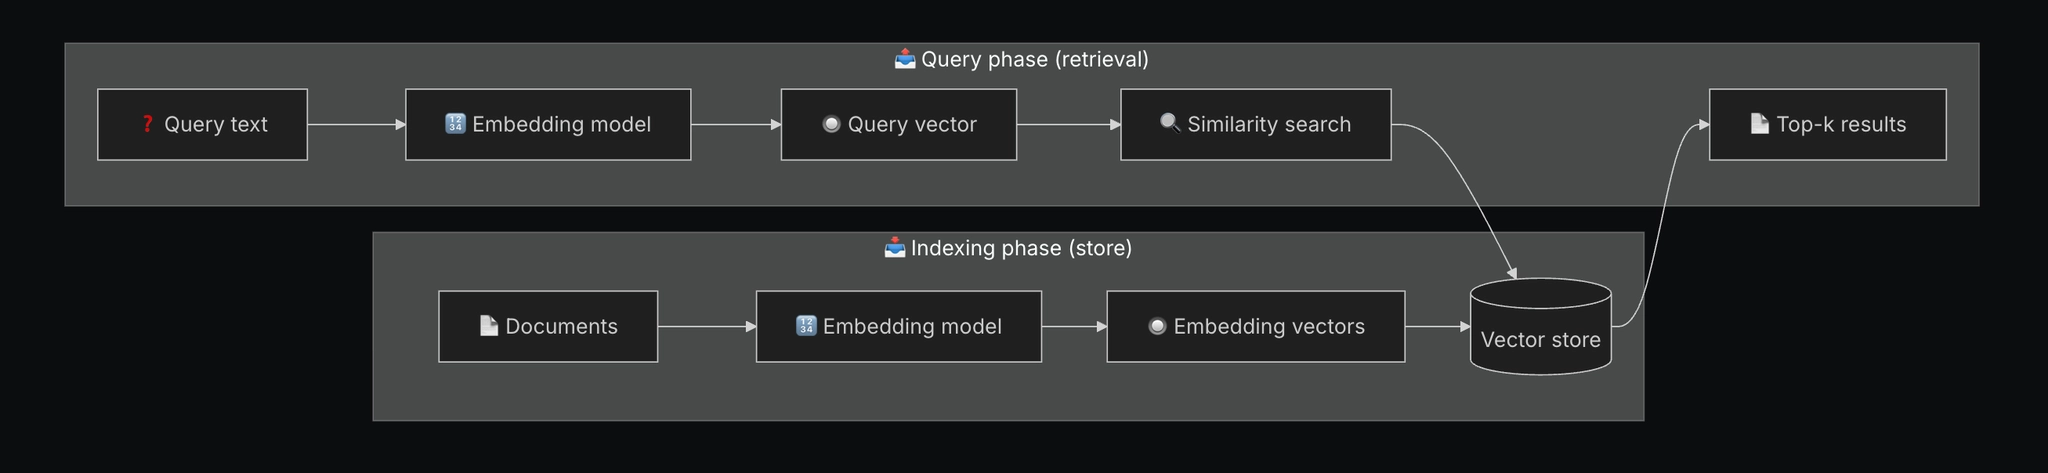

Для нашего примера мы будем использовать векторное хранилище Chroma. 

Chroma выбирают как оптимальный вариант для большинства RAG-систем благодаря простоте, скорости и полной локальности. Он бесплатный, open-source, хорошо интегрирован с LangChain и поддерживает постоянное хранение данных на диске без сложной настройки.



In [7]:
from langchain_chroma import Chroma
from pathlib import Path
import uuid
import time
import shutil
from itertools import groupby

persist_directory = str(Path("./chroma_db").resolve())

# source уже есть в metadata каждого чанка — нормализуем до имени файла
for chunk in chunks:
    src = chunk.metadata.get("source", "")
    chunk.metadata["filename"] = Path(src).name

# очищаем старую базу если есть
if Path(persist_directory).exists():
    shutil.rmtree(persist_directory)
    print(f"🗑 Старая база удалена")

print(f"📁 База: {persist_directory}")
print(f"⏳ Всего чанков: {len(chunks)}\n")

# группируем чанки по файлу (порядок сохраняется)
groups = {k: list(v) for k, v in groupby(chunks, key=lambda c: c.metadata.get("filename", "?"))}

vectorstore = None
total_added = 0
start_total = time.time()

for filename, file_chunks in groups.items():
    ids = [str(uuid.uuid4()) for _ in file_chunks]
    start = time.time()

    if vectorstore is None:
        vectorstore = Chroma.from_documents(
            documents=file_chunks,
            embedding=embeddings,
            ids=ids,
            persist_directory=persist_directory,
            collection_metadata={"hnsw:space": "cosine"},
        )
    else:
        vectorstore.add_documents(file_chunks, ids=ids)

    elapsed = time.time() - start
    total_added += len(file_chunks)
    remaining = len(chunks) - total_added
    speed = len(file_chunks) / elapsed  # чанков/сек

    print(f"  ✅ {filename}: +{len(file_chunks)} чанков за {elapsed:.1f}с  "
          f"({speed:.1f} чанк/с)  |  итого: {total_added}/{len(chunks)}  |  осталось: ~{remaining/speed:.0f}с")

elapsed_total = time.time() - start_total
print(f"\n✅ Chroma: {vectorstore._collection.count()} чанков сохранено")
print(f"⏱ Общее время: {elapsed_total:.1f} сек\n")

# проверка метадаты
all_ids = list({c.metadata.get("filename") for c in chunks})
sample = vectorstore._collection.get(limit=3, include=["metadatas"])
print("📋 Пример метадаты первых 3 чанков:")
for i, meta in enumerate(sample["metadatas"]):
    print(f"  [{i}] {meta}")

📁 База: /home/emkex/life/capital/areas/code/ai_engineer/6_week/chroma_db
⏳ Всего чанков: 45

  ✅ MATH_EV_PCA.pdf: +19 чанков за 61.0с  (0.3 чанк/с)  |  итого: 19/45  |  осталось: ~84с
  ✅ MATH_limits.pdf: +14 чанков за 36.3с  (0.4 чанк/с)  |  итого: 33/45  |  осталось: ~31с
  ✅ ML3.pdf: +12 чанков за 49.6с  (0.2 чанк/с)  |  итого: 45/45  |  осталось: ~0с

✅ Chroma: 45 чанков сохранено
⏱ Общее время: 146.9 сек

📋 Пример метадаты первых 3 чанков:
  [0] {'filename': 'MATH_EV_PCA.pdf', 'source': 'materials/MATH_EV_PCA.pdf'}
  [1] {'filename': 'MATH_EV_PCA.pdf', 'source': 'materials/MATH_EV_PCA.pdf'}
  [2] {'filename': 'MATH_EV_PCA.pdf', 'source': 'materials/MATH_EV_PCA.pdf'}


### **Retriever**

Далее нам необходимо превратить полученное векторное хранилище (Chroma) в **retriever** – объект, который умеет принимать текстовый запрос и возвращать *k наиболее релевантных фрагментов* из базы:

Это упрощённый слой между хранилищем и LLM: он делает семантический поиск, чтобы модель получала только нужные документы, а не всю базу. В данном случае retriever будет каждый раз возвращать **5 лучших совпадений**.

- Дополнительные параметры
    - `search_kwargs` – задаёт тонкие настройки поиска.
    - `k` – сколько документов вернуть;
    - `score_threshold` – минимальное значение сходства для строгого поиска;
    - `fetch_k` и `lambda_mult` используются для MMR, чтобы контролировать баланс между релевантностью и разнообразием;
    - `filter` позволяет выбирать документы по метаданным (например, по автору или источнику).
    
    Всё это делает retriever гибким инструментом для точной настройки RAG.

In [8]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

## **II. Поиск и генерация**

Приложения RAG обычно работают следующим образом:

1. **Извлечение (Retrieve)**: на основе пользовательского ввода из хранилища извлекаются соответствующие фрагменты с помощью [Retrieval](https://docs.langchain.com/oss/python/langchain/retrieval#retrievers).
2. **Генерация**: [**модель**](https://docs.langchain.com/oss/python/langchain/models) выдаёт ответ на запрос пользователя. Но перед генерацией ответа, к запросу подмешивается контекст, полученный из retrieval.

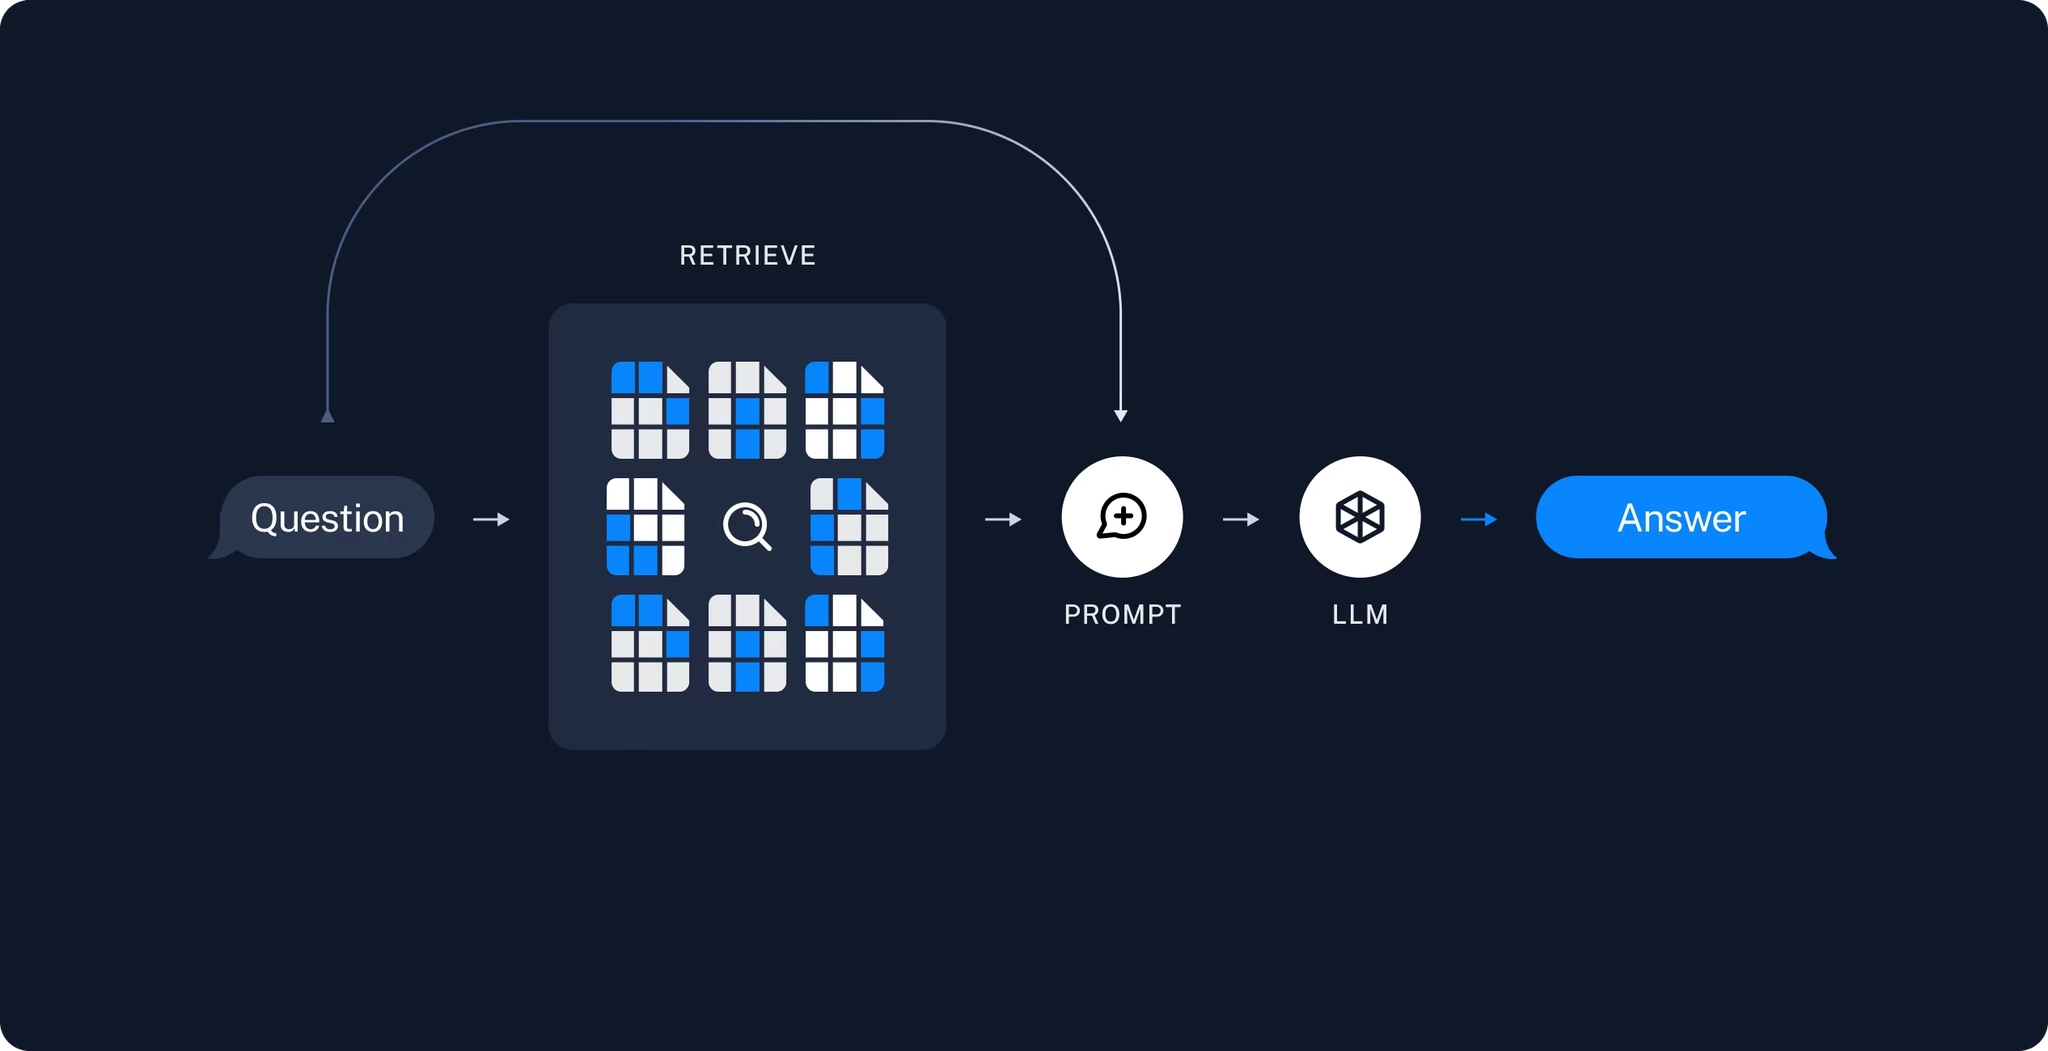

### Системный промпт

**Системный промпт** – это заранее заданная инструкция, которая определяет поведение модели: её стиль ответа, роль, тон, ограничения и правила рассуждений. В отличие от пользовательского запроса, системный промпт всегда имеет более высокий приоритет – он задаёт рамки, внутри которых работает LLM. Именно системный промпт позволяет превратить “просто языковую модель” в эксперта: юриста, аналитика, учителя, ассистента поддержки или в узкоспециализированную RAG-систему, отвечающую строго по данным.

Короткий список того, что можно настроить системным промптом:

- **Роль модели** (эксперт, юрист, ассистент, аналитик и т.д.).
- **Стиль ответа** (кратко, формально, дружелюбно, строго технически).
- **Тональность** (нейтральная, обучающая, профессиональная).
- **Формат вывода** (списки, таблицы, JSON, пошаговые инструкции).
- **Правила поведения** (отвечай только на основе контекста, не фантазируй, указывай источники).
- **Уровень детализации** (коротко, глубоко, поверхностно, с пояснениями).
- **Язык и стиль формулировок** (русский, английский, деловой, простым языком).
- **Ограничения** (не выходить за рамки темы, не использовать внешние знания, избегать спекуляций).
- **Стратегию рассуждений** (логические шаги, структурированное объяснение, сравнение вариантов).

### Библиотека промптов

Промпт можно составить вручную или воспользоваться библиотекой промптов от `langsmith`:

In [9]:
from langsmith import Client

prompt = Client().pull_prompt("rlm/rag-prompt")

Под капотом мы просто делаем запрос на LangChain Hub (библиотека промптов) и получаем объект класса PromptTemplate из langchain_core.prompts:

In [ ]:
'''
PromptTemplate(
    input_variables=['context', 'question'],
    input_types={},
    partial_variables={},
    template="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don't know the answer, just say that you don't know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"
)
'''

print('template downloaded: ', prompt)

'\nPromptTemplate(\n    input_variables=[\'context\', \'question\'],\n    input_types={},\n    partial_variables={},\n    template="You are an assistant for question-answering tasks. Use the following pieces of retrieved context to answer the question. If you don\'t know the answer, just say that you don\'t know. Use three sentences maximum and keep the answer concise.\nQuestion: {question} \nContext: {context} \nAnswer:"\n)\n'

### Составляем промпт вручную

Если мы хотим модернизировать промпт или добавить свои условия (например ответ строго на русском языке), то нам необходимо составить промпт вручную:

In [11]:
from langchain_core.prompts import ChatPromptTemplate

prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are a precise analytical assistant specializing in statistics, "
        "chemometrics and data analysis. "
        "Always respond in the same language the user used in their question. "
        "Rules:\n"
        "- Answer ONLY based on the provided context\n"
        "- If the answer is not in the context, say so directly — do not guess\n"
        "- Do not use external knowledge or make assumptions\n"
        "- Be concise but complete — include formulas, steps, or examples if present in context\n"
        "- If context contains contradictions, point them out\n"
        "- Always end your answer with: Sources: [list the source filenames used]"
    ),
    (
        "human",
        "Context:\n{context}\n\nQuestion: {question}"
    ),
])

В коде мы создаём объект `ChatPromptTemplate`, который объединяет два сообщения – системное (`system`) и пользовательское (`human`) – в единый промпт-шаблон. Шаблон служит входом для LLM в RAG-пайплайне и определяет структуру данных, которые будут переданы модели при каждом вызове.

Системное сообщение задаёт жёсткие правила выполнения: модель должна всегда возвращать ответ на русском языке, игнорировать языки контекста, использовать только предоставленный фрагмент данных и ограничиваться тремя предложениями. Это фактически конфиг, который определяет поведение модели на уровне протокола общения.

Пользовательское сообщение содержит параметры `{context}` и `{question}`, которые подставляются рантаймом. Они выступают интерфейсом между `retriever`'ом, который генерирует контекст, и LLM, которая генерирует ответ.

В итоге `prompt` – это параметризованный шаблон, который принимает словарь вида `{"context": "...", "question": "..."}` и генерирует финальный промпт, полностью совместимый с форматом чат-моделей LangChain.

### Модель

Следующий компонент нашей RAG системы – LLM модель (не та же самая, что для создания эмбедингов). 

В RAG-пайплайне модель (LLM) – это компонент, который принимает подготовленный промпт и на его основе генерирует итоговый ответ. Retriever предоставляет релевантные данные (формирует контекст), а LLM интерпретирует их, резюмирует, структурирует и формирует человекочитаемый вывод. Без модели RAG – это просто поиск; модель превращает результаты поиска в связный и осмысленный ответ.

Критерии выбора: поддерживаемый контекстный размер, качество reasoning, способность работать с русским языком, доступность инструмента в стеке (OpenAI, Ollama, Together, OpenRouter и др.). В RAG частое требование – модель, которая хорошо читает длинный контекст и не "галлюцинирует".

In [14]:
# Будем использовать модель с поддержкой Русского языка:
# ollama pull gemma3:4b

from langchain_openai import ChatOpenAI

OLLAMA_BASE_URL = 'http://127.0.0.1:11434/v1'
LLM_MODEL = 'gemma3:4b'

llm = ChatOpenAI(
    api_key='None',
    base_url=OLLAMA_BASE_URL,
    model=LLM_MODEL,
    temperature=0.2,  # для более точных ответов
)

llm.invoke('Привет! Ты кто?')

AIMessage(content='Привет! Я — большая языковая модель, разработанная компанией Google DeepMind. Меня зовут Gemma, и я доступна для общественности. Я являюсь моделью с открытыми весами.\n', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 41, 'prompt_tokens': 14, 'total_tokens': 55, 'completion_tokens_details': None, 'prompt_tokens_details': None}, 'model_provider': 'openai', 'model_name': 'gemma3:4b', 'system_fingerprint': 'fp_ollama', 'id': 'chatcmpl-892', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019dabd9-35f1-7071-88f0-36ce5c8dd0af-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 14, 'output_tokens': 41, 'total_tokens': 55, 'input_token_details': {}, 'output_token_details': {}})

### LangChain цепочка

На данном этапе у нас уже есть все ключевые компоненты RAG-системы: эмбеддинговая модель преобразует текст в вектора, векторное хранилище позволяет эффективно искать релевантные фрагменты, LLM отвечает за генерацию финального ответа, а промпт задаёт строгие правила обработки контекста. Каждый из этих элементов выполняет свою роль в общей архитектуре и обеспечивает точность, управляемость и воспроизводимость ответа.

Однако сами по себе эти компоненты не образуют рабочий пайплайн – их необходимо связать в единый поток данных. Нам нужно определить, как запрос пользователя передаётся в retriever, как найденные документы форматируются, как они попадают в промпт и как затем передаются модели. За координацию всех этих шагов отвечает цепочка LangChain, которая позволяет собрать весь процесс в понятный и детерминированный конвейер.

Именно для этого мы создаём RAG-chain: объект, который описывает полный маршрут данных – от входного вопроса до финального текстового ответа. В данном случае цепочка объединяет retriever, форматтер документов, промпт, модель и парсер результата. Ниже приведён финальный вариант цепочки, который превращает набор разрозненных модулей в готовый RAG-процесс.

In [15]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough


def format_docs(docs):
    formatted = []
    for doc in docs:
        source = doc.metadata.get("source", "unknown_source")
        page = doc.metadata.get("page", None)

        header = f"Source: {source}"
        if page is not None:
            header += f" | Page: {page}"

        text = doc.page_content.strip()

        formatted.append(f"{header}\n{text}")

    return "\n\n---\n\n".join(formatted)

# Chain
rag_chain = (
    {"context": retriever | format_docs, "question": RunnablePassthrough()}
    | prompt
    | llm
    | StrOutputParser()
)

Этот код создаёт *цепочку обработки данных* в стиле LangChain – по сути, конвейер, где каждый шаг передаёт результат следующему. Синтаксис построен на операторе `|`, который работает как "передай дальше". Вместо того чтобы вручную вызывать функции одна за другой, мы собираем их в единую структуру, которая автоматически выполняет все этапы в нужном порядке.

Первый блок – это словарь с двумя ключами: "`context`" и "`question`". Для `context` используется конструкция `retriever | format_docs`, что означает: сначала выполнить поиск по базе (`retriever`), затем отформатировать найденные документы (`format_docs`). Для "`question`" указано `RunnablePassthrough()`, и это просто означает: "передать вопрос пользователя дальше без изменений". Этот словарь формирует входные данные для промпта.

Дальше данные проходят через три этапа: `prompt` (подстановка в шаблон), `llm` (генерация ответа моделью) и `StrOutputParser()` (приведение результата к обычной строке). Таким образом, каждая часть кода – это модуль в цепочке, а оператор `|` связывает их в линейный поток. Итоговый объект `rag_chain` – это готовая RAG-цепочка, которую можно вызывать как обычную функцию, передавая ей вопрос, и она сама выполнит весь процесс от поиска до генерации ответа.

In [16]:
# Question
rag_chain.invoke("В чем отличие стохастического градиентного спуска от Adam?")

'Стохастический градиентный спуск (SDG) использует один случайный пример для вычисления градиента, в то время как Adam использует скользящие средние первого и второго моментов градиента, а также коррекцию смещения. Sources: materials/ML3.pdf'

ответ далек от идеала по ряду причин:
- исходные данные не идеально обработаны (основной пробел)
- моделька легкая (как и все требования, специально подбирались легкие, чтобы не перегружать ноут и быстро получить ответ)

Пилотный запуск произошел :)